# Social Media Influence over teenagers Mental Health
---

# Importing Libraries
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Identifying Desired Data Set + Basic EDA Work
---


In [ ]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
print('File Imported!')

File Imported!


In [ ]:
print("Data shape:", df.shape) # Rows and Columns
print("\nData types:")
print(df.dtypes) 
print('\nData head:') # First 5 rows
df.head()


Data shape: (1200, 13)

Data types:
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

Data head:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


# Exploring Missing Values
---


In [ ]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)

if missing.sum() == 0:
    print('\nNo missing values found!')
else:
    print(f'\nTotal missing values: {missing.sum()}')

Missing values per column:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

No missing values found!


# Displaying Some Essential Stats
---

In [6]:
df.describe()



,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


### How many teens do you think are experiencing depression in the Sample??

---




In [7]:
nums = df['depression_label'].value_counts()

print("Depression Counts:")
print(f" NO signs of Depression (0) :{nums[0]}")
print(f" Signs of Depression (1): {nums[1]}")

Depression_Rate = round((nums[1] / len(df)), 2)

print(f"Depresion Rate = {Depression_Rate}")


Depression Counts:
 NO signs of Depression (0) :1169
 Signs of Depression (1): 31
Depresion Rate = 0.03


### Let's Visualize Social media daily use
---

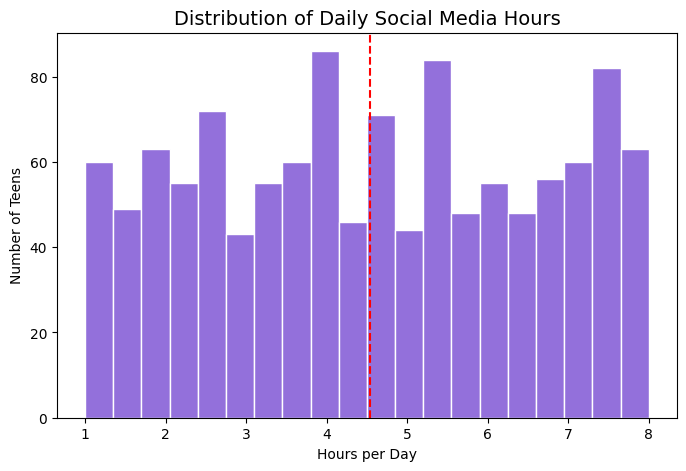

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df['daily_social_media_hours'], bins=20, color='mediumpurple', edgecolor='white')
plt.title('Distribution of Daily Social Media Hours', fontsize=14)
plt.xlabel('Hours per Day')
plt.ylabel('Number of Teens')
plt.axvline(df['daily_social_media_hours'].mean(), color='red', linestyle='--',
            label=f'Mean = {df["daily_social_media_hours"].mean():.1f} hrs')

plt.show()

### 

## Now let's explore the relation between those who suffer depression with their social interaction level
---


In [9]:
df['low_social'] = (df['social_interaction_level'] == 'low').astype(int)

In [10]:
dep = df[df['depression_label'] == 1]['low_social'].mean()
non_dep = df[df['depression_label'] == 0]['low_social'].mean()

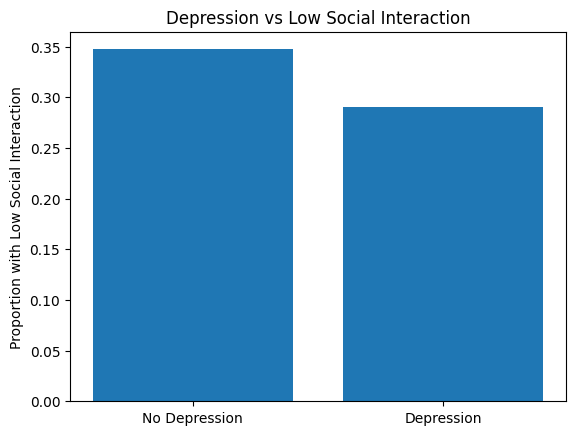

In [11]:
import matplotlib.pyplot as plt

plt.bar(['No Depression', 'Depression'], [non_dep, dep])
plt.ylabel('Proportion with Low Social Interaction')
plt.title('Depression vs Low Social Interaction')
plt.show()

In [1]:
print('We can conclude that depression and low social interaction are not related as there is a smaller proportion of depressed having low interactions than those who have no depression')

We can conclude that depression and low social interaction are not related as there is a smaller proportion of depressed having low interactions than those who have no depression


## Social Interaction Distribution by Depression Status

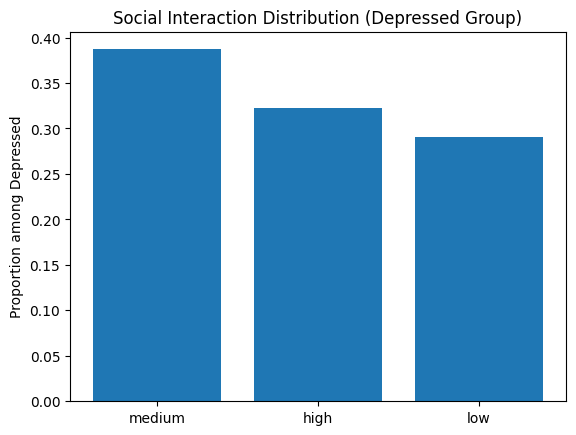

social_interaction_level
medium    12
high      10
low        9
Name: count, dtype: int64


In [19]:

proportions = counts / counts.sum()
counts = depressed['social_interaction_level'].value_counts()

plt.bar(proportions.index, proportions.values)
plt.ylabel('Proportion among Depressed')
plt.title('Social Interaction Distribution (Depressed Group)')
plt.show()
depressed = df[df['depression_label'] == 1]

counts = depressed['social_interaction_level'].value_counts()
print(counts)


In [20]:
print('From the insights, we could conclude that low social interaction is not a cause of depression and vice versa')

From the insights, we could conclude that low social interaction is not a cause of depression and vice versa


## Combining Anxiety & Stress and Addiction factors influencing Depressed and Not Depressed teens

In [14]:
factors = ['stress_level', 'anxiety_level', 'addiction_level', 'sleep_hours', 'daily_social_media_hours']
comparison = df.groupby('depression_label')[factors].mean()
comparison.index = ['No Depression', 'Depression']

print('Average values by depression status:')
print(comparison.round(2))

Average values by depression status:
               stress_level  anxiety_level  addiction_level  sleep_hours  \
No Depression          5.37           5.56             5.57         6.49   
Depression             8.48           8.61             5.32         4.76   

               daily_social_media_hours  
No Depression                      4.48  
Depression                         6.72  


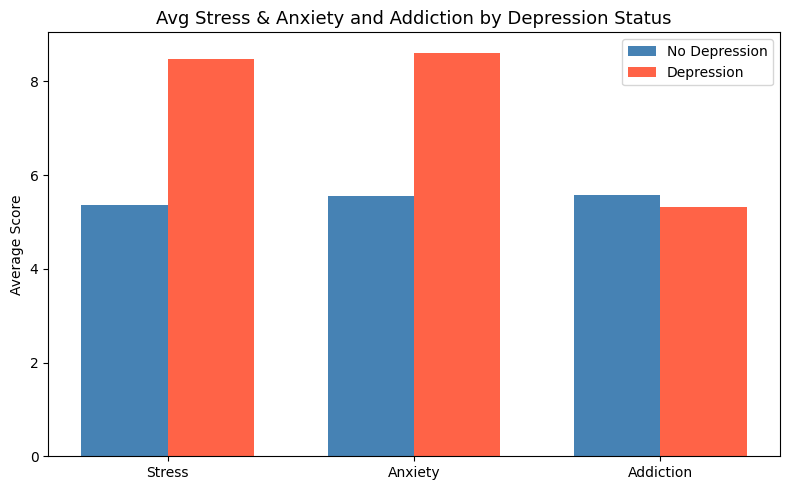

In [13]:
metrics = ['stress_level', 'anxiety_level', 'addiction_level']
labels = ['Stress', 'Anxiety', 'Addiction']

no_dep = comparison.loc['No Depression', metrics].values
dep    = comparison.loc['Depression', metrics].values

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], no_dep, width, label='No Depression', color='steelblue')
plt.bar([i + width/2 for i in x], dep,    width, label='Depression',    color='tomato')
plt.title('Avg Stress & Anxiety and Addiction by Depression Status', fontsize=13)
plt.xticks(x, labels)
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.show()

### Addiction and Platform Usage!!

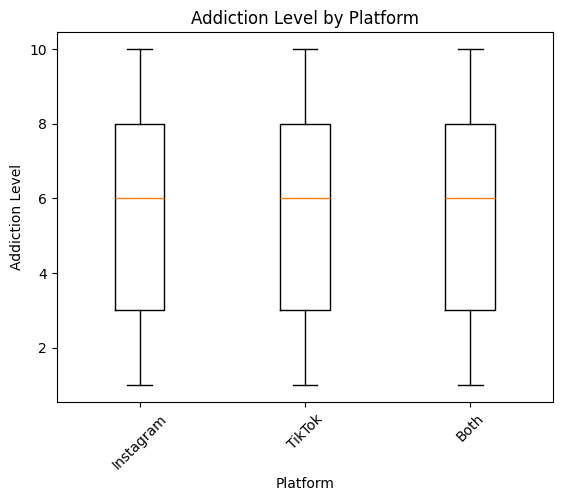

In [25]:
import matplotlib.pyplot as plt

platforms = df['platform_usage'].unique()
data = [df[df['platform_usage'] == p]['addiction_level'] for p in platforms]

plt.boxplot(data, labels=platforms)
plt.xlabel('Platform')
plt.ylabel('Addiction Level')
plt.title('Addiction Level by Platform')
plt.xticks(rotation=45)
plt.show()

## Addiction and hours of usage!

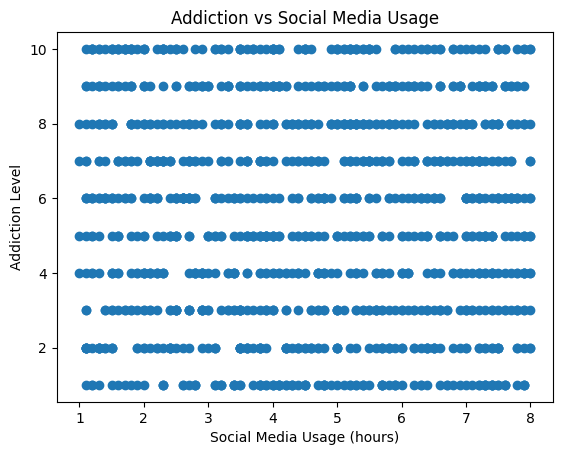

In [27]:
import matplotlib.pyplot as plt

plt.scatter(df['daily_social_media_hours'], df['addiction_level'])

plt.xlabel('Social Media Usage (hours)')
plt.ylabel('Addiction Level')
plt.title('Addiction vs Social Media Usage')

plt.show()

## Academic Perfomramnce and Social media usage

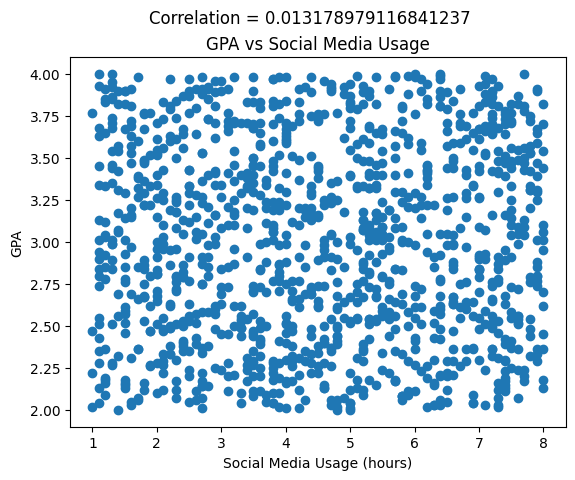

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df['daily_social_media_hours'], df['academic_performance'])

plt.xlabel('Social Media Usage (hours)')
plt.ylabel('GPA')
corr = df['daily_social_media_hours'].corr(df['academic_performance'])
plt.title('GPA vs Social Media Usage')

plt.suptitle(f"Correlation = {corr}")

plt.show()

In [1]:
print(' There is a non linear relationship between Social media usage and GPA ' )

 There is a non linear relationship between Social media usage and GPA 


## Depression by Gender
---

Depression rate by gender:
  female: 2.9%
  male: 2.3%


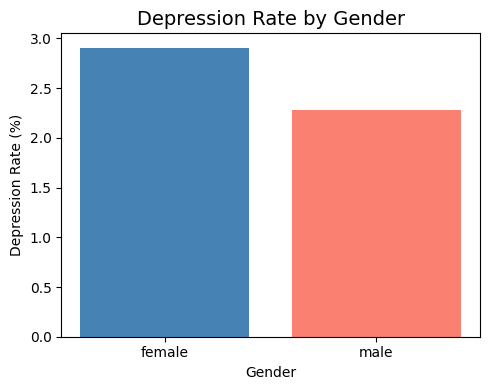

In [10]:
depression_by_gender = df.groupby('gender')['depression_label'].mean() * 100

print('Depression rate by gender:')
for gender, rate in depression_by_gender.items():
    print(f'  {gender}: {rate:.1f}%')

plt.figure(figsize=(5, 4))
plt.bar(depression_by_gender.index, depression_by_gender.values,
        color=['steelblue', 'salmon'])
plt.title('Depression Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Depression Rate (%)')
plt.tight_layout()
plt.show()

# Summary
---

In [21]:
depression_rate = df['depression_label'].mean()*100

average_social_media_use = df['daily_social_media_hours'].mean()

average_sleep_hours = df['sleep_hours'].mean()

print(" INSIGHTS ")
print(f'\n Dataset: {df.shape[0]} teens, {df.shape[1]} features')
print(f'\n Depression rate overall: {depression_rate:.1f}%')
print(f'\n Average daily social media usage: {average_social_media_use:.1f} hours')
print(f' Average sleep hours: {average_sleep_hours:.1f} hours')


 INSIGHTS 

 Dataset: 1200 teens, 13 features

 Depression rate overall: 2.6%

 Average daily social media usage: 4.5 hours
 Average sleep hours: 6.4 hours
